In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import datetime
from IQAEBinom_OnlyFinalRound_EndCIReachTol import IQAEBinom_OnlyFinalRound_EndCIReachTol

In [2]:
nGrover = 200
nShotUnit = 1
epsilon = 0.001
alpha = 0.05

In [3]:
r = 150
thetal = 0.5 * np.pi * r / (2 * nGrover + 1)
thetau = 0.5 * np.pi * (r + 1) / (2 * nGrover + 1)
pl = np.sin(thetal) ** 2
pu = np.sin(thetau) ** 2
print(pl, pu)

nPoints = 50
ps = np.linspace(pl, pu, nPoints)

0.30730197944308646 0.31092245535700463


0.30730197944308646 2023-09-05 13:03:08.062228
0.3073758667066358 2023-09-05 13:03:22.459554
0.30744975397018515 2023-09-05 13:03:39.332082
0.3075236412337345 2023-09-05 13:03:54.153570
0.30759752849728383 2023-09-05 13:04:06.121834
0.30767141576083323 2023-09-05 13:04:16.326589
0.3077453030243826 2023-09-05 13:04:26.087188
0.3078191902879319 2023-09-05 13:04:32.435987
0.30789307755148126 2023-09-05 13:04:37.891574
0.3079669648150306 2023-09-05 13:04:43.013164
0.30804085207857995 2023-09-05 13:04:47.497657
0.3081147393421293 2023-09-05 13:04:51.834289
0.30818862660567864 2023-09-05 13:04:56.087733
0.30826251386922804 2023-09-05 13:05:00.690508
0.3083364011327774 2023-09-05 13:05:05.382156
0.3084102883963267 2023-09-05 13:05:10.513923
0.30848417565987607 2023-09-05 13:05:15.726006
0.3085580629234254 2023-09-05 13:05:21.327732
0.30863195018697476 2023-09-05 13:05:26.704047
0.3087058374505241 2023-09-05 13:05:32.026908
0.30877972471407344 2023-09-05 13:05:37.207436
0.30885361197762284 202

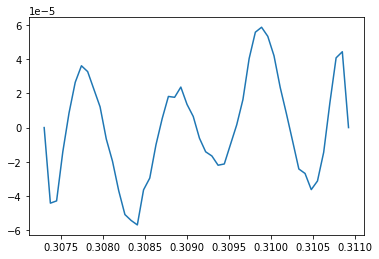

In [4]:
nEstim = 10000
errMeans = []

for p in ps:
    print(p, datetime.datetime.now())
    errs = []
    for i in range(nEstim):
        result = IQAEBinom_OnlyFinalRound_EndCIReachTol(p, nGrover, epsilon, alpha, nShotUnit)
        errs.append(result["Estimate"] - p)
    errMeans.append(np.mean(errs))

ax = plt.gca()
plt.plot(ps, errMeans)
plt.show()

0.30730197944308646 2023-09-05 13:08:48.085909


<ipython-input-5-f34daed3f954>:16: RuntimeWarning: Mean of empty slice
  errMean = np.nanmean(errs)


nan 0
0.3073758667066358 2023-09-05 13:08:56.536381
0.0007320433809342997 1
0.30744975397018515 2023-09-05 13:09:05.010617
0.0006514316516629856 27
0.3075236412337345 2023-09-05 13:09:14.024435
0.0005786022762330529 147
0.30759752849728383 2023-09-05 13:09:22.985977
0.0005048667022019623 345
0.30767141576083323 2023-09-05 13:09:31.863714
0.0004499508830185945 857
0.3077453030243826 2023-09-05 13:09:40.923784
0.00038067131079414537 1560
0.3078191902879319 2023-09-05 13:09:49.690062
0.0003204770665175384 2508
0.30789307755148126 2023-09-05 13:09:58.569814
0.00025691081521711685 3600
0.3079669648150306 2023-09-05 13:10:06.625308
0.00019682335281979562 4796
0.30804085207857995 2023-09-05 13:10:13.775092
0.00013983294378191877 5744
0.3081147393421293 2023-09-05 13:10:20.741630
8.349515478538382e-05 6757
0.30818862660567864 2023-09-05 13:10:27.943701
3.905511249430633e-05 7442
0.30826251386922804 2023-09-05 13:10:35.174678
-3.1338952455067885e-06 7939
0.3083364011327774 2023-09-05 13:10:42.4

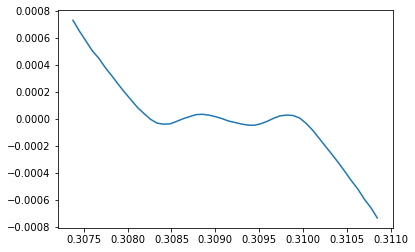

In [5]:
# 次のroundに行く場合はNaNとする
nEstim = 10000
minRatio = 2
errMeans = []
numEnds = []

for p in ps:
    print(p, datetime.datetime.now())
    errs = []
    for i in range(nEstim):
        result = IQAEBinom_OnlyFinalRound_EndCIReachTol(p, nGrover, epsilon, alpha, nShotUnit, minRatio=2)
        if result is None:
            errs.append(np.nan)
        else:
            errs.append(result["Estimate"] - p)
    errMean = np.nanmean(errs)
    numEnd = nEstim - np.sum(np.isnan(errs))
    print(errMean, numEnd)
    errMeans.append(errMean)
    numEnds.append(numEnd)

ax = plt.gca()
plt.plot(ps, errMeans)
plt.show()